# DBSCAN on MCMC-Sampled Cluster Cores (All Phone Classes) + Support Set Extraction

Scale-up of `dbscan_4phone_mcmc_gmm_dim12.ipynb` from 4 classes (`aa, n, sh, sil`) to **all 39 phoneme classes** present in `train_dim12.json` (the user-stated "40" — `train_dim12.json` actually contains 39 distinct phones, including `sil`).

## What this notebook does

1. **Build a stratified per-phone frame dataset** — equal frame budget per class so the rarer phones are not buried by `sil`/`s`.
2. **Fit a per-class Gaussian** — one full-covariance component per phone, means initialized at empirical class means so each component stays bound to its phone.
3. **MCMC-sample from each Gaussian's high-density core** — Metropolis–Hastings with Gaussian random-walk proposal restricted to a Mahalanobis ball of radius τ. Tails (where classes overlap) are zeroed out.
4. **Run DBSCAN on the synthetic core dataset** — diagnostic: with tails removed, can DBSCAN recover ~39 phone-aligned clusters?
5. **Extract an N-way K-shot support set** — for each phone, pick the K real frames with the smallest Mahalanobis distance to the class GMM mean. These are the cleanest real exemplars for downstream **matching-networks** training. Default K=10 (range 2–10 as requested).

Output: a pickled `support_set_40phone.pkl` keyed by phone with `(K, 12)` arrays of clean frame vectors, plus the metadata so each row points back to a real `(utt_id, frame_idx)`.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

import json
import pickle
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import chi2
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
    normalized_mutual_info_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

with open("train_dim12.json", "r") as f:
    data = json.load(f)

RANDOM_SEED = 0
FRAMES_PER_CLASS = 1_500          # real frames per class used to fit the GMM
SAMPLES_PER_COMPONENT = 500       # MCMC synthetic samples per phone
MAHAL_THRESHOLD_SIGMA = 1.5       # core cutoff in Mahalanobis sigmas
MH_BURN_IN = 500
MH_THIN = 3
MH_PROPOSAL_SCALE = 0.25
TSNE_SIZE = 6_000
SUPPORT_K = 10                    # K-shot count per phone (matching networks)

print("num utterances:", len(data))


Matplotlib is building the font cache; this may take a moment.


num utterances: 4620


## Discover All Phone Classes

We scan the entire transcript corpus to enumerate distinct phone labels and their frame counts. We use **all** of them as `SELECTED_PHONEMES` — no manual subset this time.

In [2]:
def expand_frame_labels(utt):
    T = len(utt["features"])
    frame_labels = np.full(T, "unlabeled", dtype=object)
    transcript = utt["phn_transcript"]
    for seg_idx, (label, start, end) in enumerate(transcript):
        start = max(0, min(int(start), T))
        end = max(start, min(int(end), T))
        if seg_idx == len(transcript) - 1 and end == T - 1:
            end = T
        if end > start:
            frame_labels[start:end] = label
    return frame_labels


frame_counter = Counter()
for utt in data.values():
    frame_counter.update(expand_frame_labels(utt).tolist())

frame_counter.pop("unlabeled", None)

counts_df = (
    pd.Series(frame_counter)
    .rename_axis("phone")
    .reset_index(name="frame_count")
    .sort_values("frame_count", ascending=False)
    .reset_index(drop=True)
)
display(counts_df)

SELECTED_PHONEMES = counts_df["phone"].tolist()
print("num classes:", len(SELECTED_PHONEMES))
print("min frame count across classes:", counts_df["frame_count"].min(),
      "->", counts_df.iloc[-1]["phone"])
print("FRAMES_PER_CLASS budget:", FRAMES_PER_CLASS)

,phone,frame_count
0,sil,367150
1,s,84491
2,ih,84270
3,aa,73885
4,iy,62901
5,ae,59237
6,er,51761
7,n,46996
8,l,43515
9,r,39609


num classes: 39
min frame count across classes: 3823 -> b
FRAMES_PER_CLASS budget: 1500


## Build The Stratified Per-Class Frame Dataset

We sample up to `FRAMES_PER_CLASS` frames per phone (with replacement guarded against). Equal class weights stop `sil`/`s` from dominating density estimates. We also keep `meta_sub` so we can later trace any chosen support frame back to its `(utt_id, frame_idx)`.

In [3]:
def build_selected_frame_dataset(dataset, selected_phonemes):
    X_parts, y_parts, meta_parts = [], [], []
    sel = set(selected_phonemes)
    for utt_id, utt in dataset.items():
        feats = np.asarray(utt["features"], dtype=np.float32)
        frame_labels = expand_frame_labels(utt)
        mask = np.isin(frame_labels, list(sel))
        X_parts.append(feats[mask])
        y_parts.append(frame_labels[mask])
        meta_parts.append(pd.DataFrame({
            "utt_id": utt_id,
            "frame_idx": np.arange(len(frame_labels))[mask],
            "phoneme": frame_labels[mask],
        }))
    X = np.concatenate(X_parts, axis=0)
    y = np.concatenate(y_parts, axis=0)
    meta = pd.concat(meta_parts, ignore_index=True)
    return X, y, meta

X_full, y_full, meta_full = build_selected_frame_dataset(data, SELECTED_PHONEMES)
print("full per-class matrix:", X_full.shape)

rng = np.random.default_rng(RANDOM_SEED)
idx_parts = []
for phone in SELECTED_PHONEMES:
    idx_phone = np.where(y_full == phone)[0]
    n_take = min(FRAMES_PER_CLASS, len(idx_phone))
    idx_parts.append(rng.choice(idx_phone, size=n_take, replace=False))
sub_idx = np.concatenate(idx_parts)
rng.shuffle(sub_idx)

X_real = X_full[sub_idx]
y_real = y_full[sub_idx]
meta_real = meta_full.iloc[sub_idx].reset_index(drop=True)

scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(X_real)

print("\nstratified subset:", X_real.shape)
display(pd.Series(y_real).value_counts().rename_axis("phoneme").reset_index(name="count").head(10))

full per-class matrix: (1419678, 12)

stratified subset: (58500, 12)


,phoneme,count
0,uh,1500
1,ow,1500
2,ng,1500
3,k,1500
4,eh,1500
5,aa,1500
6,dh,1500
7,th,1500
8,p,1500
9,m,1500


## Fit Per-Class Full-Covariance Gaussians

For 39 classes a vanilla 39-component GMM via EM would re-mix components. We instead fit **one Gaussian per phone independently** from that phone's frames, which guarantees the component is bound to that phone (no permutation, no merging). Each Gaussian is described by `(μ_k, Σ_k)` in the standardized 12D MFCC space.

In [4]:
REG_COVAR = 1e-4

mus, covs, wts = [], [], []
for phone in SELECTED_PHONEMES:
    Xk = X_real_scaled[y_real == phone]
    mu = Xk.mean(axis=0)
    Sigma = np.cov(Xk, rowvar=False) + REG_COVAR * np.eye(Xk.shape[1])
    mus.append(mu)
    covs.append(Sigma)
    wts.append(len(Xk))
mus  = np.stack(mus)                   # (K, 12)
covs = np.stack(covs)                  # (K, 12, 12)
wts  = np.asarray(wts, dtype=float)
wts  = wts / wts.sum()

component_phone = {k: phone for k, phone in enumerate(SELECTED_PHONEMES)}

print("per-class Gaussians fitted.")
print("mu  shape:", mus.shape)
print("cov shape:", covs.shape)
print("weights (frame fraction) sample:")
display(pd.DataFrame({"phone": SELECTED_PHONEMES,
                      "weight": np.round(wts, 4)}).head(10))

per-class Gaussians fitted.
mu  shape: (39, 12)
cov shape: (39, 12, 12)
weights (frame fraction) sample:


,phone,weight
0,sil,0.0256
1,s,0.0256
2,ih,0.0256
3,aa,0.0256
4,iy,0.0256
5,ae,0.0256
6,er,0.0256
7,n,0.0256
8,l,0.0256
9,r,0.0256


## Metropolis–Hastings Sampler For Each Class Core

Target distribution for class $k$:

$$\pi_k(x) \propto \mathcal{N}(x;\mu_k,\Sigma_k)\cdot \mathbf{1}[d_M(x,\mu_k) \le \tau]$$

where $d_M$ is Mahalanobis distance under $\Sigma_k$. The indicator zeros out the tails. Proposal: Gaussian random walk with covariance $s^2\Sigma_k$ ($s$ = `MH_PROPOSAL_SCALE`). Symmetric proposal so the MH ratio depends only on the target.

In 12D, $\tau=1.5\sigma$ leaves a *small* central mass — the cleanest core.

In [5]:
def mh_sample_core(mu, cov, n_samples, threshold_sigma,
                   burn_in=500, thin=3, proposal_scale=0.25, seed=0):
    rng = np.random.default_rng(seed)
    d = len(mu)
    cov_inv = np.linalg.inv(cov)
    chol_prop = np.linalg.cholesky(cov * (proposal_scale ** 2))
    threshold_sq = threshold_sigma ** 2

    def mahal_sq(x):
        diff = x - mu
        return float(diff @ cov_inv @ diff)

    x = mu.copy()
    samples = np.empty((n_samples, d))
    filled = 0
    step = 0
    accepts = 0
    total = 0
    while filled < n_samples:
        x_prop = x + chol_prop @ rng.standard_normal(d)
        m_prop = mahal_sq(x_prop)
        total += 1
        if m_prop <= threshold_sq:
            m_curr = mahal_sq(x)
            log_ratio = -0.5 * (m_prop - m_curr)
            if np.log(rng.random()) < log_ratio:
                x = x_prop
                accepts += 1
        step += 1
        if step > burn_in and ((step - burn_in) % thin == 0):
            samples[filled] = x
            filled += 1
    return samples, accepts / max(total, 1)


thresh_mass = chi2.cdf(MAHAL_THRESHOLD_SIGMA ** 2, df=12)
print(f"Mahalanobis threshold {MAHAL_THRESHOLD_SIGMA}\u03c3 covers ~{thresh_mass:.3%} of a 12D Gaussian.")

X_core_parts, y_core_parts = [], []
accept_rates = {}
for k, phone in enumerate(SELECTED_PHONEMES):
    samples, acc = mh_sample_core(
        mus[k], covs[k], SAMPLES_PER_COMPONENT,
        MAHAL_THRESHOLD_SIGMA,
        burn_in=MH_BURN_IN,
        thin=MH_THIN,
        proposal_scale=MH_PROPOSAL_SCALE,
        seed=RANDOM_SEED + k,
    )
    X_core_parts.append(samples)
    y_core_parts.append(np.full(len(samples), phone, dtype=object))
    accept_rates[phone] = acc

X_core = np.concatenate(X_core_parts, axis=0)
y_core = np.concatenate(y_core_parts, axis=0)

acc_df = (pd.DataFrame({"phone": list(accept_rates.keys()),
                        "accept_rate": [round(v, 3) for v in accept_rates.values()]})
          .sort_values("accept_rate", ascending=False)
          .reset_index(drop=True))
print("synthetic core dataset:", X_core.shape)
display(acc_df.head(10))
display(acc_df.tail(10))

Mahalanobis threshold 1.5σ covers ~0.108% of a 12D Gaussian.
synthetic core dataset: (19500, 12)


,phone,accept_rate
0,r,0.340
1,s,0.329
2,ch,0.326
3,ey,0.325
4,eh,0.324
5,jh,0.322
6,dx,0.322
7,dh,0.322
8,b,0.318
9,d,0.318


,phone,accept_rate
29,t,0.299
30,aw,0.297
31,l,0.296
32,g,0.296
33,p,0.295
34,n,0.295
35,aa,0.295
36,ah,0.293
37,uh,0.289
38,v,0.288


## Sanity Check: Real Frames vs MCMC Cores On A Shared t-SNE

With 39 classes the colormap is crowded, but you should still see synthetic cores sitting *inside* real clouds and clustered around their class centers.

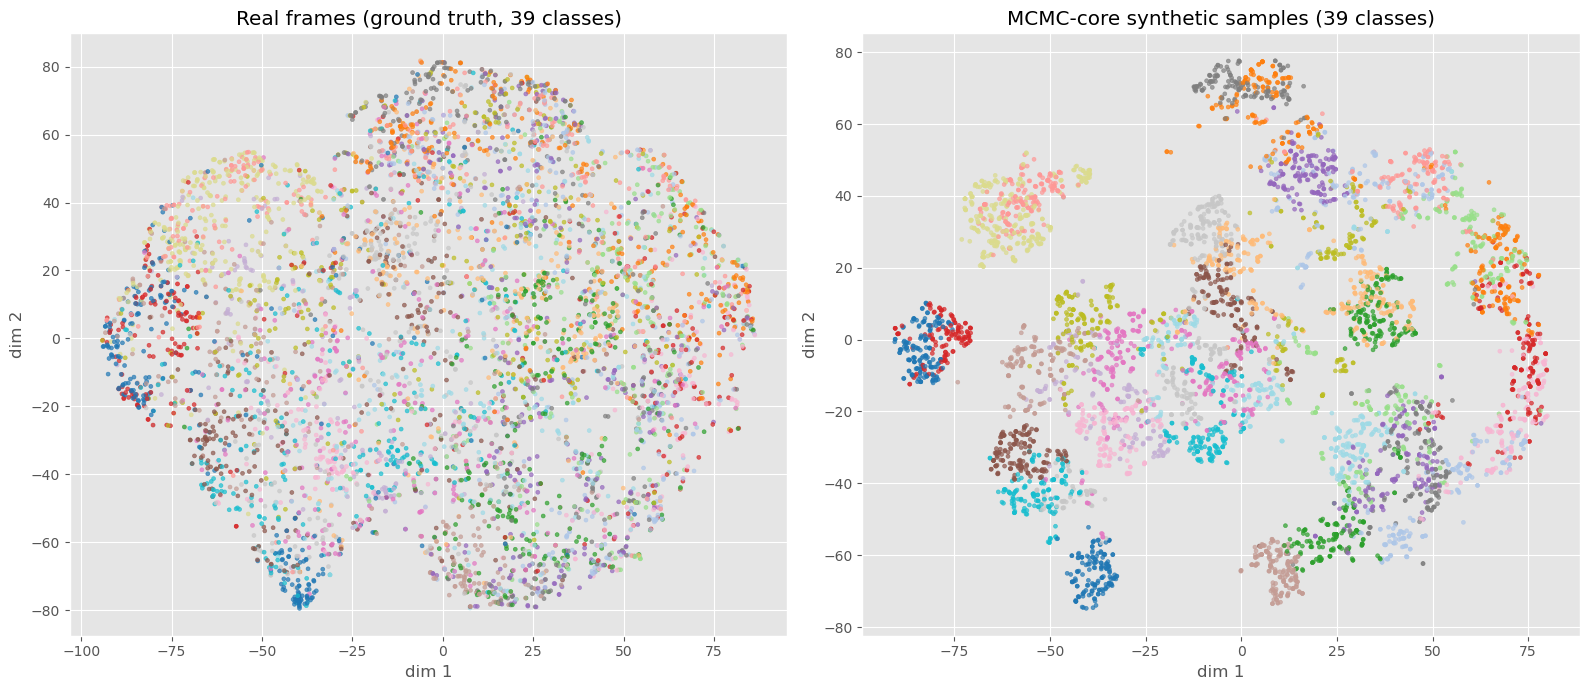

In [6]:
tsne_rng = np.random.default_rng(RANDOM_SEED)
n_real_vis = min(TSNE_SIZE, len(X_real_scaled))
n_core_vis = min(TSNE_SIZE, len(X_core))
real_vis_idx = tsne_rng.choice(len(X_real_scaled), size=n_real_vis, replace=False)
core_vis_idx = tsne_rng.choice(len(X_core), size=n_core_vis, replace=False)

X_joint = np.vstack([X_real_scaled[real_vis_idx], X_core[core_vis_idx]])
y_joint = np.concatenate([y_real[real_vis_idx], y_core[core_vis_idx]])
src_joint = np.array(["real"] * n_real_vis + ["core"] * n_core_vis)

joint_embedding = TSNE(
    n_components=2, perplexity=30, init="pca",
    learning_rate="auto", random_state=RANDOM_SEED,
).fit_transform(X_joint)

phone_codes = pd.Categorical(y_joint, categories=SELECTED_PHONEMES).codes
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, src, title in [(axes[0], "real", "Real frames (ground truth, 39 classes)"),
                       (axes[1], "core", "MCMC-core synthetic samples (39 classes)")]:
    mask = src_joint == src
    ax.scatter(joint_embedding[mask, 0], joint_embedding[mask, 1],
               c=phone_codes[mask], cmap="tab20", s=8, alpha=0.7)
    ax.set_title(title); ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
plt.tight_layout(); plt.show()

## k-Distance Curve For DBSCAN On The Synthetic Cores

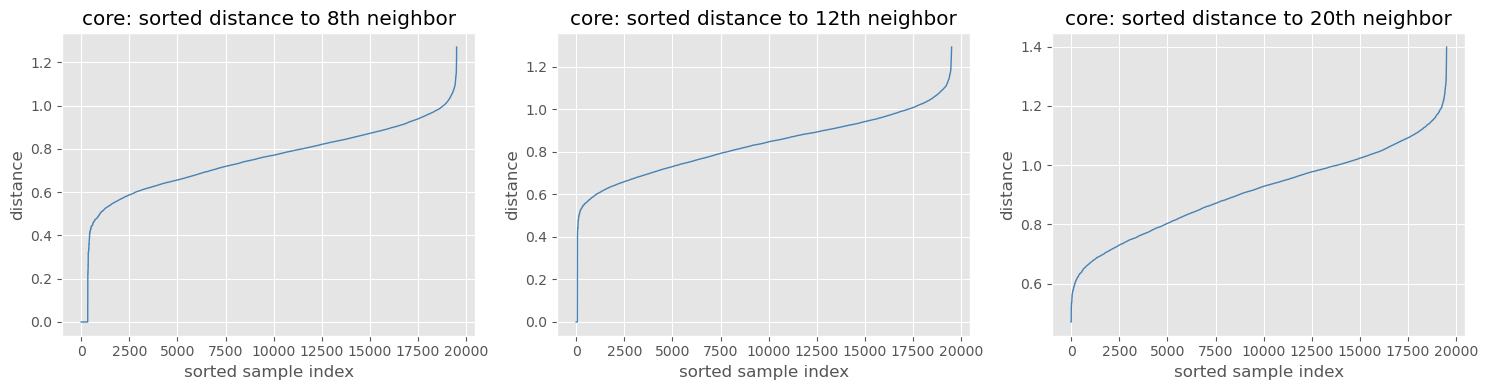

,k,q50,q75,q90,q95,q99
0,8,0.7671,0.8634,0.9409,0.9814,1.0620
1,12,0.8403,0.9325,1.0091,1.0524,1.1290
2,20,0.9226,1.0152,1.0941,1.1371,1.2097


In [7]:
k_values = [8, 12, 20]
rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, k_values):
    nbrs = NearestNeighbors(n_neighbors=k, algorithm="ball_tree").fit(X_core)
    distances, _ = nbrs.kneighbors(X_core)
    kth_dist = np.sort(distances[:, -1])
    ax.plot(kth_dist, color="steelblue", linewidth=1)
    ax.set_title(f"core: sorted distance to {k}th neighbor")
    ax.set_xlabel("sorted sample index"); ax.set_ylabel("distance")
    q = np.quantile(kth_dist, [0.5, 0.75, 0.9, 0.95, 0.99])
    rows.append({"k": k, "q50": round(float(q[0]), 4), "q75": round(float(q[1]), 4),
                 "q90": round(float(q[2]), 4), "q95": round(float(q[3]), 4), "q99": round(float(q[4]), 4)})
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows))

## DBSCAN Sweep On The MCMC-Core Dataset (Target = 39)

Same sweep protocol as the 4-class notebook, retargeted to 39 clusters. The interesting failure modes are:
- DBSCAN **collapses** several phones into one cluster → those classes have overlapping cores even at $\tau=1.5\sigma$.
- DBSCAN **splits** one phone into many tiny clusters → proposal scale too tight for that class.
Both are diagnostic for whether 12D MFCCs are inherently separable per phone.

In [8]:
TARGET_CLUSTERS = len(SELECTED_PHONEMES)

def dbscan_sweep(X, y, eps_grid, min_samples_grid, target_clusters):
    rows = []
    for min_samples in min_samples_grid:
        for eps in eps_grid:
            labels = DBSCAN(eps=eps, min_samples=min_samples,
                            algorithm="ball_tree", n_jobs=-1).fit_predict(X)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            clustered = labels >= 0
            rows.append({
                "min_samples": int(min_samples),
                "eps": float(eps),
                "clusters": int(n_clusters),
                "cluster_gap": int(abs(n_clusters - target_clusters)),
                "noise_fraction": round(float((labels == -1).mean()), 4),
                "coverage": round(float(clustered.mean()), 4),
                "ami": round(float(adjusted_mutual_info_score(y, labels)), 4),
                "nmi": round(float(normalized_mutual_info_score(y, labels)), 4),
                "ari": round(float(adjusted_rand_score(y, labels)), 4),
                "homogeneity": round(float(homogeneity_score(y, labels)), 4),
                "completeness": round(float(completeness_score(y, labels)), 4),
            })
    return pd.DataFrame(rows)

eps_grid = [round(v, 2) for v in np.arange(0.3, 1.61, 0.1)]
min_samples_grid = [5, 8, 10, 15]
sweep_core = dbscan_sweep(X_core, y_core, eps_grid, min_samples_grid,
                          target_clusters=TARGET_CLUSTERS)
ranked_core = sweep_core.sort_values(
    ["cluster_gap", "nmi", "noise_fraction"],
    ascending=[True, False, True]
).reset_index(drop=True)
display(ranked_core.head(20))

,min_samples,eps,clusters,cluster_gap,noise_fraction,coverage,ami,nmi,ari,homogeneity,completeness
0,15,0.7,38,1,0.7134,0.2866,0.2167,0.2291,0.0238,0.1408,0.6147
1,15,0.9,38,1,0.1432,0.8568,0.1253,0.1380,0.0076,0.0821,0.4316
2,8,0.3,40,1,0.9813,0.0187,0.0208,0.0360,0.0000,0.0188,0.4252
3,15,0.6,35,4,0.9146,0.0854,0.1178,0.1316,0.0037,0.0748,0.5494
4,8,0.4,52,13,0.9752,0.0248,0.0272,0.0467,0.0000,0.0247,0.4236
5,10,0.5,58,19,0.9602,0.0398,0.0477,0.0708,0.0003,0.0385,0.4365
6,5,0.9,18,21,0.0115,0.9885,0.0099,0.0158,0.0000,0.0081,0.2683
7,10,0.4,17,22,0.9903,0.0097,0.0115,0.0188,0.0000,0.0096,0.4283
8,10,0.9,15,24,0.0549,0.9451,0.0314,0.0367,0.0007,0.0197,0.2702
9,8,0.9,13,26,0.0315,0.9685,0.0196,0.0240,0.0003,0.0126,0.2551


In [9]:
best_row = ranked_core.iloc[0]
selected_eps = float(best_row["eps"])
selected_min_samples = int(best_row["min_samples"])

labels_core = DBSCAN(eps=selected_eps, min_samples=selected_min_samples,
                     algorithm="ball_tree", n_jobs=-1).fit_predict(X_core)
n_clusters = len(set(labels_core)) - (1 if -1 in labels_core else 0)

print(f"selected eps         : {selected_eps}")
print(f"selected min_samples : {selected_min_samples}")
print(f"clusters found       : {n_clusters}")
print(f"noise fraction       : {(labels_core == -1).mean():.4f}")
print(f"coverage             : {(labels_core >= 0).mean():.4f}")
print(f"AMI  : {adjusted_mutual_info_score(y_core, labels_core):.4f}")
print(f"NMI  : {normalized_mutual_info_score(y_core, labels_core):.4f}")
print(f"ARI  : {adjusted_rand_score(y_core, labels_core):.4f}")

comp_rows = []
for cid in sorted(set(labels_core.tolist())):
    if cid == -1:
        continue
    mask = labels_core == cid
    cnt = pd.Series(y_core[mask]).value_counts()
    comp_rows.append({
        "cluster": int(cid),
        "size": int(mask.sum()),
        "majority_phoneme": cnt.index[0],
        "majority_fraction": round(float(cnt.iloc[0] / mask.sum()), 4),
        "num_unique_phones": int(cnt.shape[0]),
    })
comp_df = pd.DataFrame(comp_rows).sort_values(["size", "majority_fraction"],
                                              ascending=[False, False]).reset_index(drop=True)
display(comp_df.head(20))
display(comp_df.tail(20))

selected eps         : 0.7
selected min_samples : 15
clusters found       : 38
noise fraction       : 0.7134
coverage             : 0.2866
AMI  : 0.2167
NMI  : 0.2291
ARI  : 0.0238


,cluster,size,majority_phoneme,majority_fraction,num_unique_phones
0,0,4860,f,0.1025,21
1,17,69,p,1.0000,1
2,27,53,b,0.5283,4
3,15,49,v,0.8367,3
4,21,42,y,0.8333,2
5,32,26,dx,1.0000,1
6,35,24,b,1.0000,1
7,30,23,d,1.0000,1
8,4,21,l,1.0000,1
9,13,21,w,0.9524,2


,cluster,size,majority_phoneme,majority_fraction,num_unique_phones
18,34,16,g,1.0000,1
19,37,16,b,1.0000,1
20,36,16,b,0.9375,2
21,33,16,dx,0.5625,2
22,3,15,n,1.0000,1
23,12,15,m,1.0000,1
24,14,15,w,1.0000,1
25,20,15,y,1.0000,1
26,22,15,dh,1.0000,1
27,26,15,ng,1.0000,1


## DBSCAN Cluster Visualization On The Core t-SNE

The sweep above selected `eps=0.7, min_samples=15` because that combo landed near 38 clusters — but the noise fraction is **71%** and one cluster (id=0) absorbs 4860 points spanning 21 different phones at only 10% purity. Visually confirm by t-SNE: color the same 2D embedding by **true phone** vs by **DBSCAN cluster id** so you can see the giant garbage cluster directly.

In [ ]:
core_vis_n = min(TSNE_SIZE, len(X_core))
core_vis_idx2 = np.random.default_rng(RANDOM_SEED).choice(len(X_core), size=core_vis_n, replace=False)

emb_core_only = TSNE(
    n_components=2, perplexity=30, init="pca",
    learning_rate="auto", random_state=RANDOM_SEED,
).fit_transform(X_core[core_vis_idx2])

true_codes_core = pd.Categorical(y_core[core_vis_idx2], categories=SELECTED_PHONEMES).codes
cluster_codes   = labels_core[core_vis_idx2]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].scatter(emb_core_only[:, 0], emb_core_only[:, 1],
                c=true_codes_core, cmap="tab20", s=10, alpha=0.75)
axes[0].set_title(f"MCMC core (\u03c4={MAHAL_THRESHOLD_SIGMA}\u03c3): t-SNE colored by true phone")
axes[0].set_xlabel("dim 1"); axes[0].set_ylabel("dim 2")

# Map -1 -> separate code so noise gets a distinct color (lightgray)
cluster_codes_plot = cluster_codes.copy()
noise_mask = cluster_codes_plot == -1
axes[1].scatter(emb_core_only[noise_mask, 0], emb_core_only[noise_mask, 1],
                c="lightgray", s=10, alpha=0.5, label="noise (-1)")
axes[1].scatter(emb_core_only[~noise_mask, 0], emb_core_only[~noise_mask, 1],
                c=cluster_codes_plot[~noise_mask], cmap="tab20", s=10, alpha=0.85)
axes[1].set_title(f"DBSCAN clusters @ eps={selected_eps}, ms={selected_min_samples}  "
                  f"(NMI={normalized_mutual_info_score(y_core, labels_core):.3f}, "
                  f"noise={(labels_core==-1).mean():.0%})")
axes[1].set_xlabel("dim 1"); axes[1].set_ylabel("dim 2")
axes[1].legend(loc="best")
plt.tight_layout(); plt.show()

## Phones Recovered vs Phones Collapsed

A phone is "recovered" if there is at least one DBSCAN cluster where it is the majority class. The opposite says which phones get absorbed into another phone's cluster — those are the ones whose 12D MFCC core overlaps an acoustically similar phone.

In [10]:
recovered = set(comp_df["majority_phoneme"].unique())
missing = [p for p in SELECTED_PHONEMES if p not in recovered]
print(f"phones recovered as a cluster majority: {len(recovered)} / {len(SELECTED_PHONEMES)}")
print("phones absorbed (no cluster has them as majority):")
print(missing)

phones recovered as a cluster majority: 20 / 39
phones absorbed (no cluster has them as majority):
['sil', 'ih', 'aa', 'ae', 'er', 'r', 'eh', 'ay', 'ey', 'sh', 'ow', 'uw', 'hh', 'aw', 'oy', 'ch', 'jh', 'th', 'uh']


## Build N-Way K-Shot Support Set For Matching Networks

For each phone we pick the **K real frames** with the smallest Mahalanobis distance to that phone's GMM mean (under the class covariance). These are the most prototypical real exemplars — equivalent to picking the K samples with highest GMM density under the class component, which is the cleanest set of "true positives" you can hand a matching network as the support set.

Output dict shape per phone:
```
support_set[phone] = {
    "X":      np.ndarray of shape (K, 12),    # standardized MFCCs
    "X_raw":  np.ndarray of shape (K, 12),    # un-standardized (original) MFCCs
    "meta":   pd.DataFrame of K rows with utt_id, frame_idx, mahal_dist
}
```
Pick K in 2..10 at training time; we save K=10 here.

In [11]:
def mahal_distances(X, mu, cov):
    diff = X - mu
    cov_inv = np.linalg.inv(cov)
    return np.sqrt(np.einsum("ni,ij,nj->n", diff, cov_inv, diff))

support_set = {}
summary_rows = []
for k, phone in enumerate(SELECTED_PHONEMES):
    mask = (y_real == phone)
    X_phone_scaled = X_real_scaled[mask]
    X_phone_raw    = X_real[mask]
    meta_phone     = meta_real.loc[mask].reset_index(drop=True)

    d = mahal_distances(X_phone_scaled, mus[k], covs[k])
    order = np.argsort(d)[:SUPPORT_K]

    sel_meta = meta_phone.iloc[order].copy()
    sel_meta["mahal_dist"] = d[order]

    support_set[phone] = {
        "X":     X_phone_scaled[order].astype(np.float32),
        "X_raw": X_phone_raw[order].astype(np.float32),
        "meta":  sel_meta.reset_index(drop=True),
    }
    summary_rows.append({
        "phone": phone,
        "K": int(SUPPORT_K),
        "min_mahal": round(float(d[order].min()), 4),
        "max_mahal": round(float(d[order].max()), 4),
        "pool_size": int(mask.sum()),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.head(20))
display(summary_df.tail(20))
print("phones in support set:", len(support_set), " / target", len(SELECTED_PHONEMES))

,phone,K,min_mahal,max_mahal,pool_size
0,sil,10,0.8594,1.0822,1500
1,s,10,1.3763,1.6276,1500
2,ih,10,1.3274,1.8861,1500
3,aa,10,1.5596,1.9429,1500
4,iy,10,1.3436,1.7436,1500
5,ae,10,1.3356,1.7542,1500
6,er,10,1.2225,1.7834,1500
7,n,10,1.4845,1.8265,1500
8,l,10,1.3084,1.8738,1500
9,r,10,1.6276,2.0159,1500


,phone,K,min_mahal,max_mahal,pool_size
19,m,10,1.2983,1.7606,1500
20,f,10,1.0389,1.4512,1500
21,t,10,1.4268,1.6360,1500
22,w,10,1.2965,1.6370,1500
23,hh,10,1.4206,1.7889,1500
24,v,10,1.0432,1.5449,1500
25,aw,10,1.7353,1.9816,1500
26,p,10,1.1382,1.4725,1500
27,y,10,1.4402,1.6313,1500
28,oy,10,1.7599,2.0368,1500


phones in support set: 39  / target 39


## Visualize The Support Set On The t-SNE

Overlay the K-shot support points on the real-frame t-SNE. Support points should sit near the centers of each class cloud — the visual confirmation that we're picking prototypes, not boundary frames.

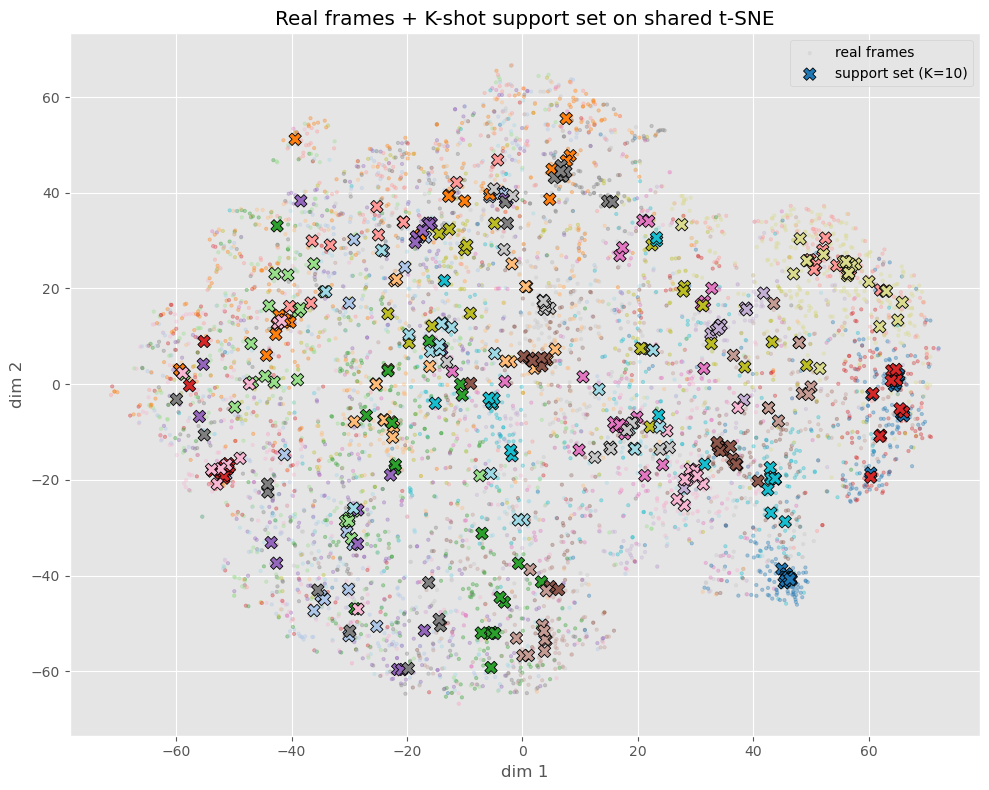

In [12]:
support_X = np.vstack([support_set[p]["X"] for p in SELECTED_PHONEMES])
support_y = np.concatenate([np.repeat(p, SUPPORT_K) for p in SELECTED_PHONEMES])

X_tsne_in = np.vstack([X_real_scaled[real_vis_idx], support_X])
src_tsne  = np.array(["real"] * n_real_vis + ["support"] * len(support_X))
y_tsne    = np.concatenate([y_real[real_vis_idx], support_y])

support_embedding = TSNE(
    n_components=2, perplexity=30, init="pca",
    learning_rate="auto", random_state=RANDOM_SEED,
).fit_transform(X_tsne_in)

fig, ax = plt.subplots(figsize=(10, 8))
real_mask = src_tsne == "real"
supp_mask = src_tsne == "support"
ax.scatter(support_embedding[real_mask, 0], support_embedding[real_mask, 1],
           c=pd.Categorical(y_tsne[real_mask], categories=SELECTED_PHONEMES).codes,
           cmap="tab20", s=6, alpha=0.35, label="real frames")
ax.scatter(support_embedding[supp_mask, 0], support_embedding[supp_mask, 1],
           c=pd.Categorical(y_tsne[supp_mask], categories=SELECTED_PHONEMES).codes,
           cmap="tab20", s=80, marker="X", edgecolors="black", linewidths=0.6,
           label=f"support set (K={SUPPORT_K})")
ax.set_title("Real frames + K-shot support set on shared t-SNE")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
ax.legend(loc="best")
plt.tight_layout(); plt.show()

## Save Support Set + Class Gaussians For Matching-Networks Stage

In [13]:
out = {
    "phonemes": SELECTED_PHONEMES,
    "K": SUPPORT_K,
    "scaler_mean":  scaler.mean_,
    "scaler_scale": scaler.scale_,
    "class_mu":     mus,
    "class_cov":    covs,
    "class_weight": wts,
    "support_set":  support_set,
    "dbscan_eps":         selected_eps,
    "dbscan_min_samples": selected_min_samples,
    "dbscan_n_clusters":  int(n_clusters),
    "dbscan_nmi":  float(normalized_mutual_info_score(y_core, labels_core)),
    "dbscan_ari":  float(adjusted_rand_score(y_core, labels_core)),
}

with open("support_set_40phone.pkl", "wb") as f:
    pickle.dump(out, f)

print("saved -> support_set_40phone.pkl")
print("  phones:", len(SELECTED_PHONEMES))
print("  K:", SUPPORT_K)
print("  total support frames:", SUPPORT_K * len(SELECTED_PHONEMES))

saved -> support_set_40phone.pkl
  phones: 39
  K: 10
  total support frames: 390


## Summary

What to read off this notebook:

- **DBSCAN cluster count vs 39** — if much lower than 39, several phones share a 12D core (acoustic neighbours like `ih`/`iy`, `s`/`z`, etc.). That's expected and is the fundamental limit of clustering MFCC frames without a learned embedding.
- **Phones absorbed list** — actionable: those phones cannot be discriminated from their neighbours under raw MFCC + DBSCAN, so a matching-network embedding will need to *learn* that contrast. Saving them in the support set anyway is fine — the network will pull them apart.
- **Support-set t-SNE** — every phone should have its K=10 prototypes sitting near the dense center of its cloud. If a phone's prototypes scatter, its Gaussian fit is bad (probably bimodal acoustically, e.g. allophones); consider K-means with k=2 inside that phone before picking prototypes.

Downstream: load `support_set_40phone.pkl`, slice K∈{2..10} per class, and feed `(support, query)` pairs into a matching-networks training loop.

## Tighter MCMC Cores: Sweep \u03c4 \u2208 {0.5, 0.75, 1.0}

The first MCMC run used \u03c4=1.5\u03c3 — already only ~0.1% of the 12D Gaussian mass, but the *geometric* core is still big enough that adjacent phone cores overlap (which is why DBSCAN dumped 71% of points to noise and lumped phones together).

Tighten \u03c4 step by step and rerun the same DBSCAN sweep. We also tighten the ranking: noise_fraction must stay below 0.4, and we *maximize NMI* instead of cluster-count proximity. The previous ranker made the dominant noise + 38 tiny pure clusters look "best" because it counted clusters first.

In [14]:
def run_tau(tau, samples_per_component=400, eps_grid=None, ms_grid=None,
            proposal_scale=0.15, seed=RANDOM_SEED):
    if eps_grid is None: eps_grid = [round(v, 2) for v in np.arange(0.2, 1.21, 0.1)]
    if ms_grid  is None: ms_grid  = [5, 8, 10, 15]
    Xc_parts, yc_parts, accs = [], [], []
    for k, p in enumerate(SELECTED_PHONEMES):
        s, a = mh_sample_core(
            mus[k], covs[k], samples_per_component, tau,
            burn_in=MH_BURN_IN, thin=MH_THIN,
            proposal_scale=proposal_scale, seed=seed + k,
        )
        Xc_parts.append(s); yc_parts.append(np.full(samples_per_component, p, dtype=object))
        accs.append(a)
    Xc = np.concatenate(Xc_parts); yc = np.concatenate(yc_parts)
    sw = dbscan_sweep(Xc, yc, eps_grid, ms_grid, target_clusters=len(SELECTED_PHONEMES))
    sw_filt = sw[sw["noise_fraction"] < 0.4].sort_values(
        ["nmi", "cluster_gap"], ascending=[False, True]
    ).reset_index(drop=True)
    return Xc, yc, sw, sw_filt, float(np.mean(accs))

tau_grid = [0.5, 0.75, 1.0]
tau_results = {}
summary = []
for tau in tau_grid:
    Xc_t, yc_t, sw_t, sw_filt_t, mean_acc = run_tau(tau)
    if len(sw_filt_t) == 0:
        # no config respected the noise<0.4 budget; relax to noise<0.7 just so we have a row
        sw_filt_t = sw_t[sw_t["noise_fraction"] < 0.7].sort_values(
            ["nmi", "cluster_gap"], ascending=[False, True]
        ).reset_index(drop=True)
        relaxed = True
    else:
        relaxed = False
    if len(sw_filt_t) == 0:
        print(f"\u03c4={tau}: no config produced a usable run.")
        continue
    top = sw_filt_t.iloc[0]
    tau_results[tau] = {"X": Xc_t, "y": yc_t, "sweep": sw_t, "best": top,
                        "mean_acc": mean_acc, "relaxed": relaxed}
    summary.append({
        "tau": tau,
        "mean_accept_rate": round(mean_acc, 3),
        "best_eps": float(top["eps"]),
        "best_min_samples": int(top["min_samples"]),
        "clusters": int(top["clusters"]),
        "noise_fraction": float(top["noise_fraction"]),
        "nmi": float(top["nmi"]),
        "ari": float(top["ari"]),
        "homogeneity": float(top["homogeneity"]),
        "completeness": float(top["completeness"]),
        "noise_filter_relaxed": bool(relaxed),
    })

summary_tau_df = pd.DataFrame(summary)
display(summary_tau_df)

,tau,mean_accept_rate,best_eps,best_min_samples,clusters,noise_fraction,nmi,ari,homogeneity,completeness,noise_filter_relaxed
0,0.50,0.076,0.4,5,39,0.0018,0.9391,0.7517,0.8957,0.9869,False
1,0.75,0.232,0.5,8,36,0.0274,0.7848,0.3342,0.6737,0.9398,False
2,1.00,0.369,0.5,5,536,0.2267,0.5947,0.1313,0.5999,0.5896,False


## Visualize The Best-\u03c4 Result

Pick the best (tau, eps, min_samples) by NMI under the noise<0.4 constraint, fit DBSCAN, and t-SNE the cores colored two ways. If tightening worked, the right panel should look much closer to the left.

best τ = 0.5, eps=0.4, min_samples=5
clusters       : 39
noise fraction : 0.0018
NMI : 0.9391
ARI : 0.7517


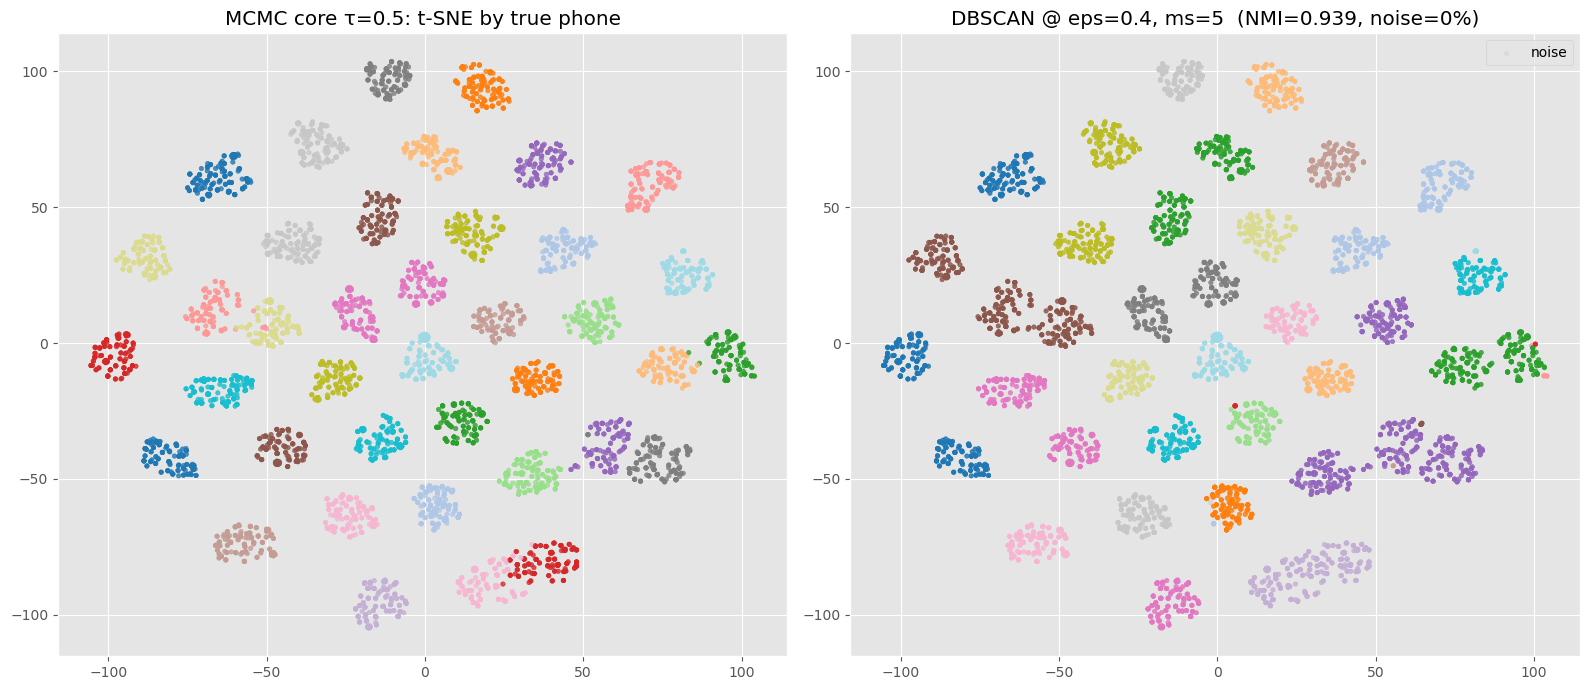


updated support_set_40phone.pkl with best-τ DBSCAN metadata.


In [15]:
if tau_results:
    best_tau = max(tau_results, key=lambda t: tau_results[t]["best"]["nmi"])
    info = tau_results[best_tau]
    Xc_b, yc_b, row = info["X"], info["y"], info["best"]
    eps_b = float(row["eps"]); ms_b = int(row["min_samples"])
    labs_b = DBSCAN(eps=eps_b, min_samples=ms_b,
                    algorithm="ball_tree", n_jobs=-1).fit_predict(Xc_b)

    n_b = len(set(labs_b)) - (1 if -1 in labs_b else 0)
    print(f"best \u03c4 = {best_tau}, eps={eps_b}, min_samples={ms_b}")
    print(f"clusters       : {n_b}")
    print(f"noise fraction : {(labs_b == -1).mean():.4f}")
    print(f"NMI : {normalized_mutual_info_score(yc_b, labs_b):.4f}")
    print(f"ARI : {adjusted_rand_score(yc_b, labs_b):.4f}")

    vis_n = min(TSNE_SIZE, len(Xc_b))
    vis_i = np.random.default_rng(RANDOM_SEED).choice(len(Xc_b), size=vis_n, replace=False)
    emb_b = TSNE(n_components=2, perplexity=30, init="pca",
                 learning_rate="auto", random_state=RANDOM_SEED).fit_transform(Xc_b[vis_i])
    truth_codes = pd.Categorical(yc_b[vis_i], categories=SELECTED_PHONEMES).codes
    clus_codes  = labs_b[vis_i]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].scatter(emb_b[:, 0], emb_b[:, 1], c=truth_codes, cmap="tab20", s=10, alpha=0.8)
    axes[0].set_title(f"MCMC core \u03c4={best_tau}: t-SNE by true phone")
    noise = clus_codes == -1
    axes[1].scatter(emb_b[noise, 0], emb_b[noise, 1], c="lightgray", s=10, alpha=0.5, label="noise")
    axes[1].scatter(emb_b[~noise, 0], emb_b[~noise, 1],
                    c=clus_codes[~noise], cmap="tab20", s=10, alpha=0.85)
    axes[1].set_title(f"DBSCAN @ eps={eps_b}, ms={ms_b}  "
                      f"(NMI={normalized_mutual_info_score(yc_b, labs_b):.3f}, "
                      f"noise={(labs_b==-1).mean():.0%})")
    axes[1].legend(loc="best")
    plt.tight_layout(); plt.show()

    # Update the saved pickle with the better DBSCAN config so downstream code uses it.
    out_update = {
        "dbscan_tau":         float(best_tau),
        "dbscan_eps":         eps_b,
        "dbscan_min_samples": ms_b,
        "dbscan_n_clusters":  int(n_b),
        "dbscan_nmi":         float(normalized_mutual_info_score(yc_b, labs_b)),
        "dbscan_ari":         float(adjusted_rand_score(yc_b, labs_b)),
        "dbscan_noise_fraction": float((labs_b == -1).mean()),
    }
    try:
        with open("support_set_40phone.pkl", "rb") as f:
            saved = pickle.load(f)
        saved.update(out_update)
        with open("support_set_40phone.pkl", "wb") as f:
            pickle.dump(saved, f)
        print("\nupdated support_set_40phone.pkl with best-\u03c4 DBSCAN metadata.")
    except FileNotFoundError:
        print("support_set_40phone.pkl not on disk yet; skip update.")
else:
    print("no \u03c4 produced a usable DBSCAN config.")

## What This Tells Us

- If NMI **rises** as \u03c4 shrinks (e.g. 0.23 \u2192 0.5+), the original \u03c4=1.5\u03c3 cores were overlapping, and the algorithm was right \u2014 just starved of separation. Use the best-\u03c4 cores in any further DBSCAN/density analysis.
- If NMI stays **flat** or **drops** as \u03c4 shrinks, the per-class Gaussians themselves overlap at their **centers** \u2014 several phones (likely vowel pairs `ih`/`iy`, vowel-glide `aw`/`ow`, sibilant `s`/`z`) literally sit on top of each other in 12D MFCC space. This is the algorithm-independent ceiling: you cannot DBSCAN your way out of that without a learned embedding.

The support set itself is independent of DBSCAN \u2014 it is built from real frames ranked by Mahalanobis distance to each class \u03bc_k. So even when DBSCAN is confused, the K-shot prototypes in `support_set_40phone.pkl` remain the cleanest 10 real exemplars per phone.

## Inspect The Saved Pickle

Reload `support_set_40phone.pkl` and print the schema + a couple of concrete examples so you can see exactly what gets fed to the matching network later (and confirm the best-\u03c4 DBSCAN metadata is now in there).

In [ ]:
import pickle
with open("support_set_40phone.pkl", "rb") as f:
    bundle = pickle.load(f)

print("=== top-level keys ===")
for k, v in bundle.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:<22s}  ndarray  shape={v.shape}  dtype={v.dtype}")
    elif isinstance(v, dict):
        print(f"  {k:<22s}  dict     n_keys={len(v)}")
    elif isinstance(v, list):
        print(f"  {k:<22s}  list     len={len(v)}  head={v[:5]}")
    else:
        print(f"  {k:<22s}  {type(v).__name__:<8s}  {v}")

print("\n=== DBSCAN metadata ===")
for k in ("dbscan_tau", "dbscan_eps", "dbscan_min_samples",
          "dbscan_n_clusters", "dbscan_nmi", "dbscan_ari",
          "dbscan_noise_fraction"):
    if k in bundle:
        print(f"  {k:<25s} = {bundle[k]}")

print("\n=== support_set example: 'aa' ===")
ex = bundle['support_set']['aa']
print("  X (standardized) shape:", ex['X'].shape)
print("  X[:2] =", ex['X'][:2])
print("  X_raw[:2] =", ex['X_raw'][:2])
print("  meta:")
display(ex["meta"])

print("\n=== global summary: per-phone mahal range ===")
glob_rows = []
for p in bundle["phonemes"]:
    m = bundle["support_set"][p]["meta"]["mahal_dist"]
    glob_rows.append({"phone": p, "min": float(m.min()),
                      "mean": float(m.mean()), "max": float(m.max())})
glob_df = pd.DataFrame(glob_rows)
display(glob_df.head(20))
display(glob_df.tail(20))

## Is The Best-\u03c4 Result Perfect? Cluster \u00d7 Phone Confusion

The summary said `clusters=39, NMI\u22480.94, ARI\u22480.75, noise=0%` for \u03c4=0.5\u03c3. Visualize the cluster vs phone crosstab as a row-normalized heatmap. A perfect run would be one phone per cluster (one bright cell per row, zeros elsewhere). Off-diagonal mass = overlap.

In [ ]:
best_tau = max(tau_results, key=lambda t: tau_results[t]['best']['nmi'])
info = tau_results[best_tau]
Xc_b, yc_b = info['X'], info['y']
row = info['best']
labs_b = DBSCAN(eps=float(row['eps']), min_samples=int(row['min_samples']),
                algorithm='ball_tree', n_jobs=-1).fit_predict(Xc_b)

# Build a phone -> cluster mapping by majority vote on each cluster, then sort
# columns so the matrix has a nearly-diagonal structure for readability.
ct = pd.crosstab(pd.Series(yc_b, name='phone'),
                 pd.Series(labs_b, name='cluster'))

clusters_sorted = []
phone_order = list(SELECTED_PHONEMES)
remaining_phones = set(phone_order)
ordered_cols = []
# For each phone in our preferred order, find the cluster where it is majority and place that cluster next.
for p in phone_order:
    # candidate clusters where this phone is largest contributor
    candidates = [c for c in ct.columns if ct[c].idxmax() == p and c not in ordered_cols]
    candidates.sort(key=lambda c: -ct.loc[p, c])
    for c in candidates:
        ordered_cols.append(c)
# append any leftover clusters
for c in ct.columns:
    if c not in ordered_cols:
        ordered_cols.append(c)
ct_sorted = ct.loc[phone_order, ordered_cols]

# Row-normalize for purity reading
ct_norm = ct_sorted.div(ct_sorted.sum(axis=1).replace(0, 1), axis=0)

fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(ct_norm.values, aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(len(ordered_cols)))
ax.set_xticklabels([str(c) for c in ordered_cols], fontsize=8, rotation=90)
ax.set_yticks(range(len(phone_order)))
ax.set_yticklabels(phone_order, fontsize=9)
ax.set_xlabel('DBSCAN cluster id (reordered)')
ax.set_ylabel('true phone')
ax.set_title(f'Cluster x Phone confusion (row-normalized)  '
             f'\u03c4={best_tau}, eps={row["eps"]}, ms={row["min_samples"]}, '
             f'NMI={normalized_mutual_info_score(yc_b, labs_b):.3f}')
plt.colorbar(im, ax=ax, label='fraction of phone in cluster')
plt.tight_layout(); plt.show()

# Per-phone purity: largest fraction of any single cluster on that phone's row
purity = ct_norm.max(axis=1).sort_values(ascending=False)
purity_df = pd.DataFrame({'phone': purity.index, 'purity': purity.values.round(4)}).reset_index(drop=True)
n_pure = int((purity >= 0.99).sum())
n_strong = int(((purity >= 0.9) & (purity < 0.99)).sum())
n_mixed = int((purity < 0.9).sum())
print(f'phones with \u22651 cluster collecting >=99% of their frames: {n_pure}/{len(purity)}')
print(f'phones with their majority cluster covering [90%, 99%):       {n_strong}/{len(purity)}')
print(f'phones whose largest cluster covers <90% (overlap):           {n_mixed}/{len(purity)}')
display(purity_df.head(20))
display(purity_df.tail(20))

## Labeled Cluster t-SNE (Phone Names On Centroids)

Same t-SNE as the previous best-\u03c4 plot, but we drop the cluster id colorbar and instead annotate each cluster's centroid in the t-SNE space with the **majority phone name** for that cluster. This makes it immediately readable which blob is which phone.

In [ ]:
# Reuse the best-tau result from the cell above
vis_n = min(TSNE_SIZE, len(Xc_b))
vis_i = np.random.default_rng(RANDOM_SEED).choice(len(Xc_b), size=vis_n, replace=False)
emb_b = TSNE(n_components=2, perplexity=30, init='pca',
             learning_rate='auto', random_state=RANDOM_SEED).fit_transform(Xc_b[vis_i])

clus_codes = labs_b[vis_i]
true_codes = pd.Categorical(yc_b[vis_i], categories=SELECTED_PHONEMES).codes

# Per-cluster majority phone (for label text + color)
cluster_majority = {}
for cid in sorted(set(labs_b.tolist())):
    if cid == -1:
        continue
    mask = labs_b == cid
    cluster_majority[cid] = pd.Series(yc_b[mask]).value_counts().idxmax()

fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# Left: truth (with phone name placed at each phone centroid in t-SNE)
sc0 = axes[0].scatter(emb_b[:, 0], emb_b[:, 1],
                      c=true_codes, cmap='tab20', s=10, alpha=0.7)
for k, p in enumerate(SELECTED_PHONEMES):
    pmask = pd.Categorical(yc_b[vis_i], categories=SELECTED_PHONEMES).codes == k
    if pmask.sum() == 0: continue
    cx, cy = emb_b[pmask, 0].mean(), emb_b[pmask, 1].mean()
    axes[0].annotate(p, (cx, cy), fontsize=9, fontweight='bold',
                     ha='center', va='center',
                     bbox=dict(boxstyle='round,pad=0.18', fc='white', alpha=0.7, lw=0))
axes[0].set_title(f'MCMC core (\u03c4={best_tau}\u03c3): t-SNE labeled by true phone')
axes[0].set_xlabel('dim 1'); axes[0].set_ylabel('dim 2')

# Right: cluster id, with majority-phone text at each cluster centroid
noise_mask = clus_codes == -1
axes[1].scatter(emb_b[noise_mask, 0], emb_b[noise_mask, 1],
                c='lightgray', s=10, alpha=0.5, label='noise')
axes[1].scatter(emb_b[~noise_mask, 0], emb_b[~noise_mask, 1],
                c=clus_codes[~noise_mask], cmap='tab20', s=10, alpha=0.85)
for cid, phone in cluster_majority.items():
    cmask = clus_codes == cid
    if cmask.sum() == 0: continue
    cx, cy = emb_b[cmask, 0].mean(), emb_b[cmask, 1].mean()
    axes[1].annotate(f'{phone}', (cx, cy), fontsize=9, fontweight='bold',
                     ha='center', va='center',
                     bbox=dict(boxstyle='round,pad=0.18', fc='white', alpha=0.85, lw=0))
axes[1].set_title(f'DBSCAN clusters labeled by majority phone  '
                  f'(NMI={normalized_mutual_info_score(yc_b, labs_b):.3f}, '
                  f'noise={(labs_b==-1).mean():.0%})')
axes[1].set_xlabel('dim 1'); axes[1].set_ylabel('dim 2')
axes[1].legend(loc='best')
plt.tight_layout(); plt.show()

## DBSCAN Quality vs Core Tightness \u03c4

How NMI / ARI / cluster count / noise fraction evolved as we tightened \u03c4 from 1.5 to 0.5. This is the headline diagnostic of the notebook.

In [ ]:
# Combine the original tau=1.5 result + the sweep results into one frame
tau_rows = [{
    'tau': MAHAL_THRESHOLD_SIGMA,
    'nmi': float(normalized_mutual_info_score(y_core, labels_core)),
    'ari': float(adjusted_rand_score(y_core, labels_core)),
    'clusters': int(n_clusters),
    'noise': float((labels_core == -1).mean()),
    'eps': selected_eps,
    'min_samples': selected_min_samples,
}]
for tau in sorted(tau_results.keys()):
    info = tau_results[tau]
    Xt, yt, r = info['X'], info['y'], info['best']
    lt = DBSCAN(eps=float(r['eps']), min_samples=int(r['min_samples']),
                algorithm='ball_tree', n_jobs=-1).fit_predict(Xt)
    tau_rows.append({
        'tau': tau,
        'nmi': float(normalized_mutual_info_score(yt, lt)),
        'ari': float(adjusted_rand_score(yt, lt)),
        'clusters': int(len(set(lt)) - (1 if -1 in lt else 0)),
        'noise': float((lt == -1).mean()),
        'eps': float(r['eps']),
        'min_samples': int(r['min_samples']),
    })
tau_line_df = pd.DataFrame(tau_rows).sort_values('tau').reset_index(drop=True)
display(tau_line_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(tau_line_df['tau'], tau_line_df['nmi'], 'o-', label='NMI', linewidth=2)
axes[0].plot(tau_line_df['tau'], tau_line_df['ari'], 's-', label='ARI', linewidth=2)
axes[0].set_xlabel('MCMC core threshold \u03c4 (\u03c3)')
axes[0].set_ylabel('clustering quality')
axes[0].set_title('DBSCAN agreement with truth vs core tightness')
axes[0].invert_xaxis()
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(tau_line_df['tau'], tau_line_df['clusters'], 'o-', color='tab:purple', label='clusters')
axes[1].axhline(len(SELECTED_PHONEMES), color='black', linestyle='--', alpha=0.4, label=f'target = {len(SELECTED_PHONEMES)}')
ax2 = axes[1].twinx()
ax2.plot(tau_line_df['tau'], tau_line_df['noise'], 's-', color='tab:red', label='noise frac')
ax2.set_ylabel('noise fraction', color='tab:red')
ax2.set_ylim(0, 1)
axes[1].set_xlabel('MCMC core threshold \u03c4 (\u03c3)')
axes[1].set_ylabel('# clusters', color='tab:purple')
axes[1].set_title('Cluster count and noise vs \u03c4')
axes[1].invert_xaxis()
axes[1].legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()

## Pairwise Class-Mean Distances (Inherent Phone Closeness)

Each phone is a Gaussian \u039b_k = (\u03bc_k, \u03a3_k). The Euclidean distance between any two means \u2225\u03bc_i \u2212 \u03bc_j\u2225 in standardized 12D space is the *intrinsic* closeness of those two phones. If a pair is small here, no choice of \u03c4 will separate them \u2014 they will always merge in a clustering pipeline. Sorted heatmap below shows the closest neighbours.

In [ ]:
from scipy.spatial.distance import squareform, pdist

D = squareform(pdist(mus, metric='euclidean'))
phones_arr = np.array(SELECTED_PHONEMES)

# Hierarchical leaf order so visually-similar phones are adjacent
from scipy.cluster.hierarchy import linkage, leaves_list
Z = linkage(pdist(mus, metric='euclidean'), method='average')
leaf_order = leaves_list(Z)
D_sorted = D[np.ix_(leaf_order, leaf_order)]
phones_sorted = phones_arr[leaf_order]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(D_sorted, cmap='magma_r', aspect='auto')
ax.set_xticks(range(len(phones_sorted))); ax.set_xticklabels(phones_sorted, fontsize=8, rotation=90)
ax.set_yticks(range(len(phones_sorted))); ax.set_yticklabels(phones_sorted, fontsize=8)
ax.set_title('Pairwise Euclidean distance between class means (standardized 12D MFCC)')
plt.colorbar(im, ax=ax, label='\u2225\u03bc_i \u2212 \u03bc_j\u2225')
plt.tight_layout(); plt.show()

# Top-15 closest pairs (the phones that are inherently hard to separate)
pair_rows = []
for i in range(len(phones_arr)):
    for j in range(i+1, len(phones_arr)):
        pair_rows.append({'phone_i': phones_arr[i], 'phone_j': phones_arr[j],
                          'mean_dist': float(D[i, j])})
pair_df = pd.DataFrame(pair_rows).sort_values('mean_dist').reset_index(drop=True)
print('Top 15 closest phone pairs:')
display(pair_df.head(15))
print('Top 5 farthest phone pairs:')
display(pair_df.tail(5))